In [1]:
import re
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams, cycler
from matplotlib.lines import Line2D
from scipy.stats import pearsonr, gaussian_kde
import sys
sys.path.append(os.path.join('c:\\',*os.getcwd().split('\\')[1:5], 'custom_modules'))
from useful_functions import get_single_unit_prediction_params

In [2]:
## Note to self: I have still not added the loaded data below to the repository

In [3]:
## load the data

datasets = {
    'onset': {},
    'peakrate': {},
    'duration': {}
}

model = 1
for key in datasets.keys():

    summary_data = {}

    data_path = os.path.join('c:\\',*os.getcwd().split('\\')[1:-2], f'data_{model}.csv')
    summary_data[f'data_{model}'] = pd.read_csv(data_path).drop(columns = 'Unnamed: 0')

    try:
        unitwise_path = os.path.join('c:\\',*os.getcwd().split('\\')[1:-2], f'm{model}_{key}_unitwise_params.csv')
        summary_data[f'm{model}_unitwise_params'] = pd.read_csv(unitwise_path).drop(columns = 'Unnamed: 0')


        fixef_path = os.path.join('c:\\',*os.getcwd().split('\\')[1:-2], f'm{model}_{key}_fixed_effects.csv')
        summary_data[f'm{model}_fixed_effects'] = pd.read_csv(fixef_path).rename(
            columns = {f'fixef(model_{model})':'fixef', 'Unnamed: 0': 'name'}
        )

    except FileNotFoundError:
        unitwise_path = os.path.join('c:\\',*os.getcwd().split('\\')[1:-2], 'oldversions', f'm{model}_{key}_unitwise_params.csv')
        summary_data[f'm{model}_unitwise_params'] = pd.read_csv(unitwise_path).drop(columns = 'Unnamed: 0')


        fixef_path = os.path.join('c:\\',*os.getcwd().split('\\')[1:-2], 'oldversions', f'm{model}_{key}_fixed_effects.csv')
        summary_data[f'm{model}_fixed_effects'] = pd.read_csv(fixef_path).rename(
            columns = {f'fixef(model_{model})':'fixef', 'Unnamed: 0': 'name'}
        )

    prediction_params = {}
    prediction_params[f'model_{model}'] = {
        'brain_area': [],
        'sign': [],
        'intercept_u': [],
        'intercept_e': [],
        'slope_u': [],
        'slope_e': [],
    }

    summary_data[f'm{model}_unitwise_params'].apply(
        get_single_unit_prediction_params, 
        model = model, 
        summary_data = summary_data, 
        prediction_params = prediction_params,
        axis = 1
    )

    prediction_params[f'model_{model}'] = pd.DataFrame(prediction_params[f'model_{model}'])
    prediction_params[f'model_{model}']['unit'] = [x[0] for x in summary_data[f'data_{model}'].groupby(['unit', 'sign']).agg(list).index.values]
    prediction_params[f'model_{model}'] = prediction_params[f'model_{model}'][
    [    'brain_area', 'unit', 'sign',
        'intercept_u', 'intercept_e',
        'slope_u', 'slope_e']
    ]

    del summary_data
    datasets[key] = prediction_params
    del prediction_params

In [4]:
## Get the V1 units that uniquely load onto PC1 and PC2

v1_xs_file = f"v1_ori_phase_condition_pcascores_wcomp.pkl"
v1_xs_file = os.path.join('c:\\',*os.getcwd().split('\\')[1:-1], v1_xs_file)
v1_pca = pd.read_pickle(v1_xs_file)
pc1_loadings = np.abs(v1_pca.components.mean(0)[0])
pc2_loadings = np.abs(v1_pca.components.mean(0)[1])

pc1_sorted_indices = np.argsort(np.abs(v1_pca.components.mean(0)[0]))[::-1]
pc2_sorted_indices = np.argsort(np.abs(v1_pca.components.mean(0)[1]))[::-1]
union = []
pc1si = []
pc2si = []
for i in range(259):
    if (pc1_sorted_indices[i]) not in union:
        pc1si.append(pc1_sorted_indices[i])
        union.append(pc1_sorted_indices[i])

    if (pc2_sorted_indices[i]) not in union:
        pc2si.append(pc2_sorted_indices[i])
        union.append(pc2_sorted_indices[i])

## Inhibition delay in V1 (Difference of enhancement vs suppression onset intercept)

In [5]:
v1_suppression_intercepts = datasets['onset'][f'model_{model}'].loc[
    ( datasets['onset'][f'model_{model}'].brain_area =='v1')
    & ( datasets['onset'][f'model_{model}'].sign == 'suppression')
].intercept_u.values

v1_enhancement_intercepts =  datasets['onset'][f'model_{model}'].loc[
    ( datasets['onset'][f'model_{model}'].brain_area =='v1')
    & ( datasets['onset'][f'model_{model}'].sign == 'enhancement')
].intercept_u.values

v1_suppression_delays = v1_suppression_intercepts - v1_enhancement_intercepts

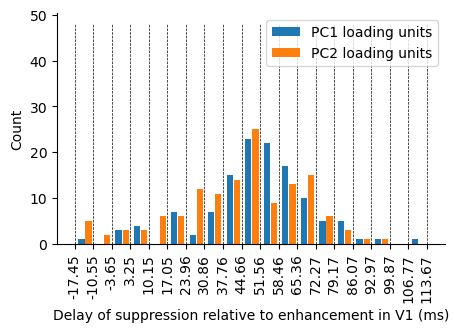

In [6]:
fig, ax = plt.subplots(figsize = (5,3))
labels = ['PC1 loading units', 'PC2 loading units']
for i, pc_group in enumerate([pc1si, pc2si]):
    x = np.linspace(
        v1_suppression_delays.min(),
        v1_suppression_delays.max(),
        20
    )
    data = v1_suppression_delays[pc_group]
    h, bins = np.histogram(data, bins = x)
    bin_centers = (bins[1:] + bins[:-1])/2
    width = np.gradient(bin_centers).mean()/3

    if i==0:
        ax.bar(bin_centers-width*0.4, h, label = labels[i], width=width)
    else:
        ax.bar(bin_centers+width*0.75, h, label = labels[i], width=width)

ax.set_xticks(bins)
ax.set_xticklabels(bins.round(2), rotation = 90)
h, _ = np.histogram(v1_suppression_delays, bins = x)
for bin_edge in bins:
    ax.plot([bin_edge]*10, np.linspace(0,h.max(),10), '--', color = 'black', linewidth = 0.5)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.legend()
ax.set_xlabel("Delay of suppression relative to enhancement in V1 (ms)")
ax.set_ylabel("Count")
plt.show()

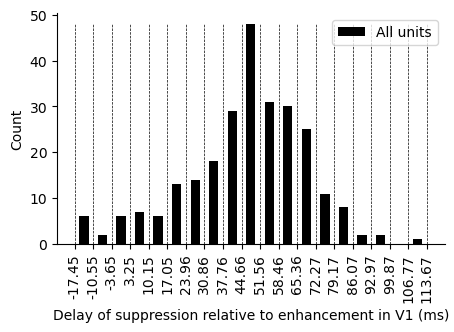

In [7]:
fig, ax = plt.subplots(figsize = (5,3))

x = np.linspace(
    v1_suppression_delays.min(),
    v1_suppression_delays.max(),
    20
)

data = v1_suppression_delays
h, bins = np.histogram(data, bins = x)
bin_centers = (bins[1:] + bins[:-1])/2
width = np.gradient(bin_centers).mean()/2

ax.bar(bin_centers, h, label = 'All units', width=width, color = 'black')
ax.set_xticks(bins)
ax.set_xticklabels(bins.round(2), rotation = 90)
for bin_edge in bins:
    ax.plot([bin_edge]*10, np.linspace(0,h.max(),10), '--', color = 'black', linewidth = 0.5)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.legend()
ax.set_xlabel("Delay of suppression relative to enhancement in V1 (ms)")
ax.set_ylabel("Count")
plt.show()

## V1 inhibition weight (V1 peak firing rate intercept)

In [8]:
v1_suppression_peakrate_intercepts =  datasets['peakrate'][f'model_{model}'].loc[
    ( datasets['peakrate'][f'model_{model}'].brain_area =='v1')
    & ( datasets['peakrate'][f'model_{model}'].sign == 'suppression')
].intercept_u.values

v1_enhancement_peakrate_intercepts =  datasets['peakrate'][f'model_{model}'].loc[
    ( datasets['peakrate'][f'model_{model}'].brain_area =='v1')
    & ( datasets['peakrate'][f'model_{model}'].sign == 'enhancement')
].intercept_u.values

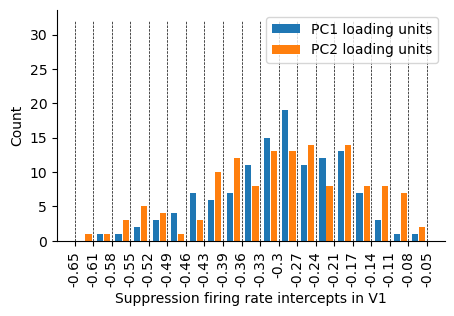

In [9]:
fig, ax = plt.subplots(figsize = (5,3))
labels = ['PC1 loading units', 'PC2 loading units']
for i, pc_group in enumerate([pc1si, pc2si]):
    x = np.linspace(
        v1_suppression_peakrate_intercepts.min(),
        v1_suppression_peakrate_intercepts.max(),
        20
    )
    data = v1_suppression_peakrate_intercepts[pc_group]
    h, bins = np.histogram(data, bins = x)
    bin_centers = (bins[1:] + bins[:-1])/2
    width = np.gradient(bin_centers).mean()/3

    if i==0:
        ax.bar(bin_centers-width*0.4, h, label = labels[i], width=width)
    else:
        ax.bar(bin_centers+width*0.75, h, label = labels[i], width=width)

ax.set_xticks(bins)
ax.set_xticklabels(bins.round(2), rotation = 90)
h, _ = np.histogram(v1_suppression_peakrate_intercepts, bins = x)
for bin_edge in bins:
    ax.plot([bin_edge]*10, np.linspace(0,h.max(),10), '--', color = 'black', linewidth = 0.5)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.legend()
ax.set_xlabel("Suppression firing rate intercepts in V1")
ax.set_ylabel("Count")
plt.show()

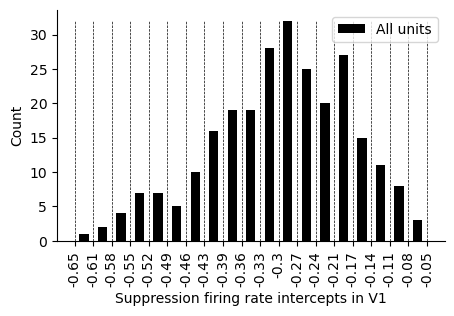

In [10]:
fig, ax = plt.subplots(figsize = (5,3))

x = np.linspace(
    v1_suppression_peakrate_intercepts.min(),
    v1_suppression_peakrate_intercepts.max(),
    20
)

data = v1_suppression_peakrate_intercepts
h, bins = np.histogram(data, bins = x)
bin_centers = (bins[1:] + bins[:-1])/2
width = np.gradient(bin_centers).mean()/2

ax.bar(bin_centers, h, label = 'All units', width=width, color = 'black')
ax.set_xticks(bins)
ax.set_xticklabels(bins.round(2), rotation = 90)
for bin_edge in bins:
    ax.plot([bin_edge]*10, np.linspace(0,h.max(),10), '--', color = 'black', linewidth = 0.5)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.legend()
ax.set_xlabel("Suppression firing rate intercepts in V1")
ax.set_ylabel("Count")
plt.show()

## dLGN frequency-time slope (dLGN enhancement onset slopes)

In [11]:
dlgn_onset_slopes =  datasets['onset'][f'model_{model}'].loc[
    ( datasets['peakrate'][f'model_{model}'].brain_area =='v1')
    & ( datasets['peakrate'][f'model_{model}'].sign == 'enhancement')
].slope_u.values


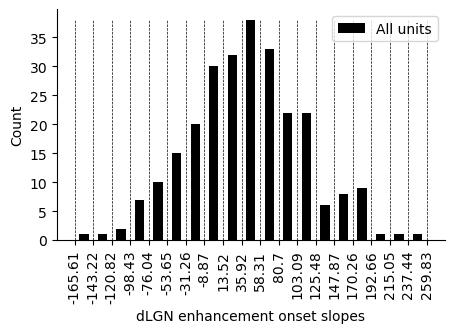

In [12]:
fig, ax = plt.subplots(figsize = (5,3))

x = np.linspace(
    dlgn_onset_slopes.min(),
    dlgn_onset_slopes.max(),
    20
)

data = dlgn_onset_slopes
h, bins = np.histogram(data, bins = x)
bin_centers = (bins[1:] + bins[:-1])/2
width = np.gradient(bin_centers).mean()/2

ax.bar(bin_centers, h, label = 'All units', width=width, color = 'black')
ax.set_xticks(bins)
ax.set_xticklabels(bins.round(2), rotation = 90)
for bin_edge in bins:
    ax.plot([bin_edge]*10, np.linspace(0,h.max(),10), '--', color = 'black', linewidth = 0.5)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.legend()
ax.set_xlabel("dLGN enhancement onset slopes")
ax.set_ylabel("Count")
plt.show()

## dLGN onset time (dLGN enhancement onset intercepts)

In [13]:
dlgn_onset_intercepts =  datasets['onset'][f'model_{model}'].loc[
    ( datasets['peakrate'][f'model_{model}'].brain_area =='v1')
    & ( datasets['peakrate'][f'model_{model}'].sign == 'enhancement')
].intercept_u.values


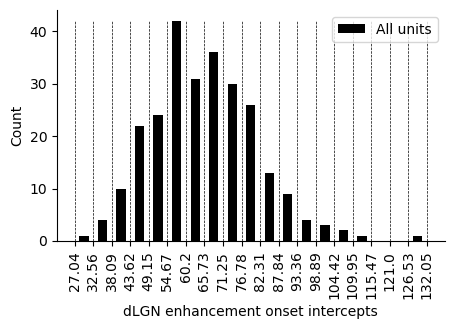

In [14]:
fig, ax = plt.subplots(figsize = (5,3))

x = np.linspace(
    dlgn_onset_intercepts.min(),
    dlgn_onset_intercepts.max(),
    20
)

data = dlgn_onset_intercepts
h, bins = np.histogram(data, bins = x)
bin_centers = (bins[1:] + bins[:-1])/2
width = np.gradient(bin_centers).mean()/2

ax.bar(bin_centers, h, label = 'All units', width=width, color = 'black')
ax.set_xticks(bins)
ax.set_xticklabels(bins.round(2), rotation = 90)
for bin_edge in bins:
    ax.plot([bin_edge]*10, np.linspace(0,h.max(),10), '--', color = 'black', linewidth = 0.5)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.legend()
ax.set_xlabel("dLGN enhancement onset intercepts")
ax.set_ylabel("Count")
plt.show()

## dLGN frequency-amplitude slope (dLGN peak firing rate slopes)

In [15]:
dlgn_peakrate_slopes =  datasets['peakrate'][f'model_{model}'].loc[
    ( datasets['peakrate'][f'model_{model}'].brain_area =='v1')
    & ( datasets['peakrate'][f'model_{model}'].sign == 'enhancement')
].slope_u.values


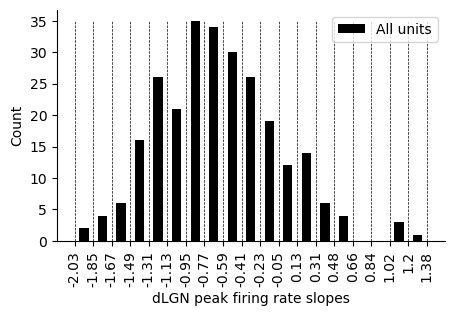

In [16]:
fig, ax = plt.subplots(figsize = (5,3))

x = np.linspace(
    dlgn_peakrate_slopes.min(),
    dlgn_peakrate_slopes.max(),
    20
)

data = dlgn_peakrate_slopes
h, bins = np.histogram(data, bins = x)
bin_centers = (bins[1:] + bins[:-1])/2
width = np.gradient(bin_centers).mean()/2

ax.bar(bin_centers, h, label = 'All units', width=width, color = 'black')
ax.set_xticks(bins)
ax.set_xticklabels(bins.round(2), rotation = 90)
for bin_edge in bins:
    ax.plot([bin_edge]*10, np.linspace(0,h.max(),10), '--', color = 'black', linewidth = 0.5)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.legend()
ax.set_xlabel("dLGN peak firing rate slopes")
ax.set_ylabel("Count")
plt.show()

## dLGN amplitude (dLGN peak firing rate intercept)

In [17]:
dlgn_peakrate_intercepts =  datasets['peakrate'][f'model_{model}'].loc[
    ( datasets['peakrate'][f'model_{model}'].brain_area =='v1')
    & ( datasets['peakrate'][f'model_{model}'].sign == 'enhancement')
].intercept_u.values


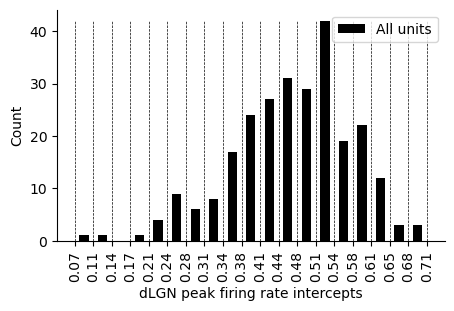

In [18]:
fig, ax = plt.subplots(figsize = (5,3))

x = np.linspace(
    dlgn_peakrate_intercepts.min(),
    dlgn_peakrate_intercepts.max(),
    20
)

data = dlgn_peakrate_intercepts
h, bins = np.histogram(data, bins = x)
bin_centers = (bins[1:] + bins[:-1])/2
width = np.gradient(bin_centers).mean()/2

ax.bar(bin_centers, h, label = 'All units', width=width, color = 'black')
ax.set_xticks(bins)
ax.set_xticklabels(bins.round(2), rotation = 90)
for bin_edge in bins:
    ax.plot([bin_edge]*10, np.linspace(0,h.max(),10), '--', color = 'black', linewidth = 0.5)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.legend()
ax.set_xlabel("dLGN peak firing rate intercepts")
ax.set_ylabel("Count")
plt.show()

## dLGN response duration (dLGN response duration intercept)

In [19]:
dlgn_duration_intercepts =  datasets['duration'][f'model_{model}'].loc[
    ( datasets['duration'][f'model_{model}'].brain_area =='v1')
    & ( datasets['duration'][f'model_{model}'].sign == 'enhancement')
].intercept_u.values


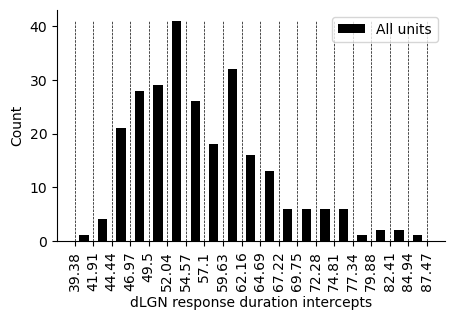

In [20]:
fig, ax = plt.subplots(figsize = (5,3))

x = np.linspace(
    dlgn_duration_intercepts.min(),
    dlgn_duration_intercepts.max(),
    20
)

data = dlgn_duration_intercepts
h, bins = np.histogram(data, bins = x)
bin_centers = (bins[1:] + bins[:-1])/2
width = np.gradient(bin_centers).mean()/2

ax.bar(bin_centers, h, label = 'All units', width=width, color = 'black')
ax.set_xticks(bins)
ax.set_xticklabels(bins.round(2), rotation = 90)
for bin_edge in bins:
    ax.plot([bin_edge]*10, np.linspace(0,h.max(),10), '--', color = 'black', linewidth = 0.5)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.legend()
ax.set_xlabel("dLGN response duration intercepts")
ax.set_ylabel("Count")
plt.show()